# 02 – Baseline CNNs (Trained from Scratch)
**Project:** AI Football Event Classifier (CNN) — Yannick Maas

The Kaggle dataset gives us **two independent single-label tasks** (event and view),
each with its own folder tree. This notebook trains **one simple CNN per task**:

- `baseline_cnn_event.pth` → predicts goal / freekick / yellowcard / …
- `baseline_cnn_view.pth`  → predicts MediumView / OuterView / ShotView / longView

Run `01_data_preparation.ipynb` first so that `outputs/manifest_events.csv` and
`outputs/manifest_views.csv` exist.


In [2]:
import os, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tqdm import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


In [ ]:
OUTPUT_DIR  = Path('outputs')
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_EPOCHS  = 10
LR          = 1e-3

EVENT_MANIFEST = OUTPUT_DIR / 'manifest_events.csv'
VIEW_MANIFEST  = OUTPUT_DIR / 'manifest_views.csv'

In [4]:
# ── Transforms & Dataset ─────────────────────────────────────────────────────
train_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
eval_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class SoccerDataset(Dataset):
    """Single-task dataset: returns (image_tensor, label_idx)."""
    def __init__(self, df, label_col, transform=None):
        self.df = df.reset_index(drop=True)
        self.label_col = label_col
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['path']).convert('RGB')
        except Exception as e:
            print(f'Error loading {row["path"]}: {e}')
            img = Image.new('RGB', IMG_SIZE)
        if self.transform: img = self.transform(img)
        return img, int(row[self.label_col])

In [5]:
# ── Simple single-head CNN ───────────────────────────────────────────────────
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(3,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128,256,3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d(4),
        )
        self.flatten  = nn.Flatten()
        self.dropout  = nn.Dropout(0.4)
        self.head     = nn.Linear(256 * 4 * 4, num_classes)
    def forward(self, x):
        return self.head(self.dropout(self.flatten(self.backbone(x))))

In [6]:
# ── Generic train/eval loop ──────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()

def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss = correct = total = 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, y in tqdm(loader, desc='train' if training else 'eval', leave=False):
            imgs, y = imgs.to(DEVICE), y.to(DEVICE)
            out = model(imgs)
            loss = criterion(out, y)
            if training:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * len(imgs)
            correct    += (out.argmax(1) == y).sum().item()
            total      += len(imgs)
    return total_loss / total, correct / total


def train_task(manifest_path: Path, label_col: str, ckpt_name: str, task_name: str):
    print(f'\n══════════ Training {task_name} classifier ══════════')
    df = pd.read_csv(manifest_path)
    classes = sorted(df['label'].unique())
    num_classes = len(classes)
    print(f'Loaded {len(df):,} rows  |  {num_classes} classes → {classes}')

    train_df = df[df['split'] == 'train']
    val_df   = df[df['split'] == 'val']
    test_df  = df[df['split'] == 'test']
    print(f'train/val/test = {len(train_df)}/{len(val_df)}/{len(test_df)}')

    train_loader = DataLoader(SoccerDataset(train_df, label_col, train_tf), batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(SoccerDataset(val_df,   label_col, eval_tf),  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader  = DataLoader(SoccerDataset(test_df,  label_col, eval_tf),  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = SimpleCNN(num_classes).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(1, NUM_EPOCHS + 1):
        tl, _    = run_epoch(model, train_loader, optimizer)
        vl, vacc = run_epoch(model, val_loader)
        scheduler.step()
        history['train_loss'].append(tl); history['val_loss'].append(vl); history['val_acc'].append(vacc)
        print(f'  Epoch {epoch:>2}: train_loss={tl:.4f}  val_loss={vl:.4f}  val_acc={vacc:.3f}')

    ckpt_path = OUTPUT_DIR / ckpt_name
    torch.save({'state_dict': model.state_dict(), 'classes': classes}, ckpt_path)
    print(f'Saved → {ckpt_path}')

    # Curves
    epochs = range(1, NUM_EPOCHS + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history['train_loss'], label='train')
    axes[0].plot(epochs, history['val_loss'],   label='val')
    axes[0].set_title(f'{task_name} – loss'); axes[0].legend()
    axes[1].plot(epochs, history['val_acc'], label='val acc', color='green')
    axes[1].set_title(f'{task_name} – val accuracy'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'baseline_{task_name}_curves.png', dpi=120)
    plt.show()

    # Test report + confusion matrix
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, y in test_loader:
            out = model(imgs.to(DEVICE))
            y_true.extend(y.numpy())
            y_pred.extend(out.argmax(1).cpu().numpy())
    print(f'\n── {task_name} test report ──')
    print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(max(6, num_classes), max(5, int(num_classes * 0.7))))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix – {task_name}')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'baseline_{task_name}_confusion_matrix.png', dpi=120)
    plt.show()

    return model, classes


══════════ Training event classifier ══════════
Loaded 1,500 rows  |  10 classes → ['corner', 'freekick', 'gattempts', 'goal', 'offside', 'playercelebration', 'plentystock', 'redc', 'spectator', 'yellowcard']
train/val/test = 1050/225/225
Parameters: 430,346


  Epoch  1: train_loss=1.7543  val_loss=1.5784  val_acc=0.422


  Epoch  2: train_loss=1.2977  val_loss=1.2766  val_acc=0.547


  Epoch  3: train_loss=1.0087  val_loss=1.0906  val_acc=0.596


  Epoch  4: train_loss=0.8586  val_loss=1.0152  val_acc=0.667


  Epoch  5: train_loss=0.7652  val_loss=0.9167  val_acc=0.676
Saved → outputs\baseline_cnn_event.pth


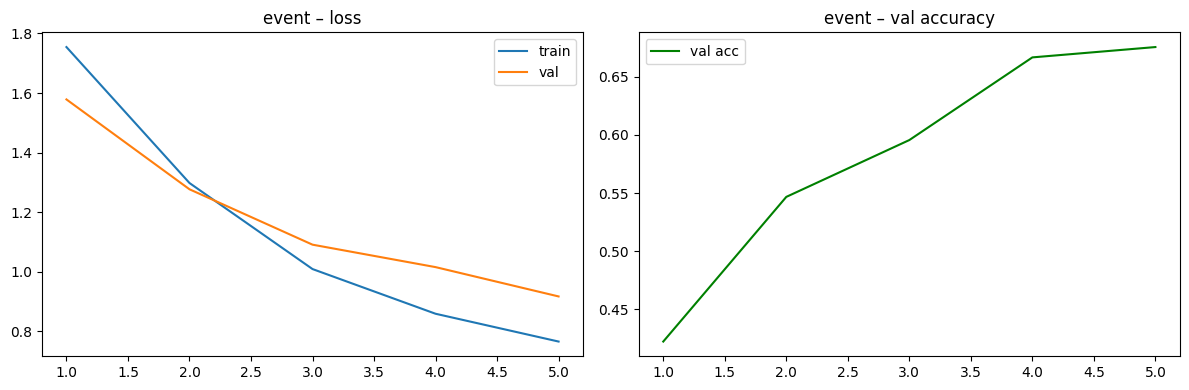


── event test report ──
                   precision    recall  f1-score   support

           corner       0.55      0.55      0.55        22
         freekick       0.69      0.48      0.56        23
        gattempts       0.66      0.86      0.75        22
             goal       0.62      0.57      0.59        23
          offside       0.92      1.00      0.96        23
playercelebration       0.77      0.45      0.57        22
      plentystock       0.40      0.43      0.42        23
             redc       0.67      0.61      0.64        23
        spectator       0.81      1.00      0.90        22
       yellowcard       0.69      0.82      0.75        22

         accuracy                           0.68       225
        macro avg       0.68      0.68      0.67       225
     weighted avg       0.68      0.68      0.67       225



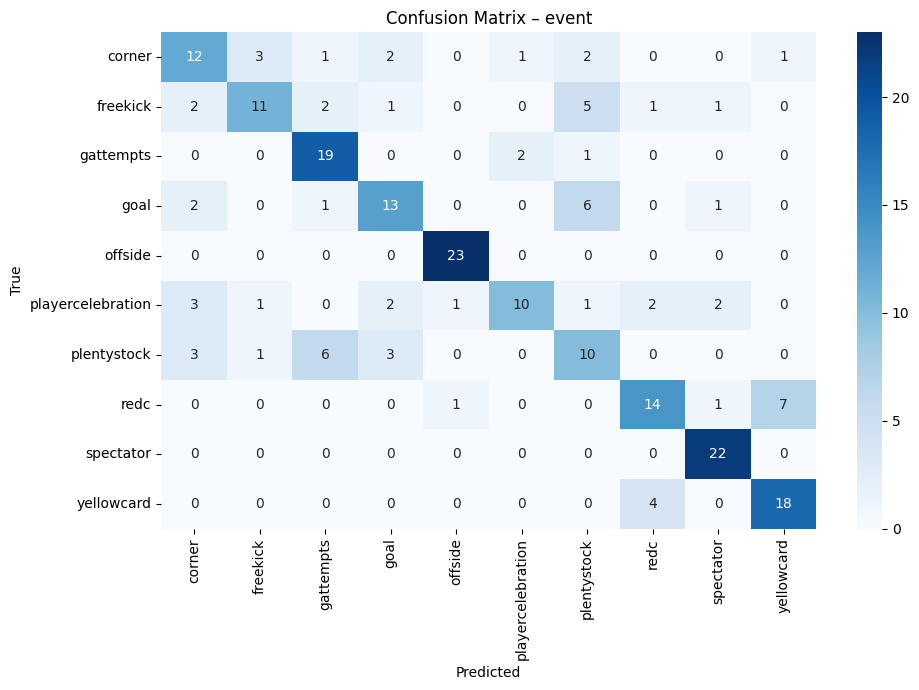

In [7]:
# ── Train EVENT classifier (goal, freekick, yellowcard, …) ──────────────────
event_model, event_classes = train_task(EVENT_MANIFEST, 'event_idx', 'baseline_cnn_event.pth', 'event')


══════════ Training view classifier ══════════
Loaded 600 rows  |  4 classes → ['MediumView', 'OuterView', 'ShotView', 'longView']
train/val/test = 420/90/90
Parameters: 405,764


  Epoch  1: train_loss=0.8427  val_loss=0.9232  val_acc=0.644


  Epoch  2: train_loss=0.5390  val_loss=0.4151  val_acc=0.889


  Epoch  3: train_loss=0.4056  val_loss=0.4524  val_acc=0.844


  Epoch  4: train_loss=0.3623  val_loss=0.4366  val_acc=0.822


  Epoch  5: train_loss=0.3169  val_loss=0.3762  val_acc=0.856
Saved → outputs\baseline_cnn_view.pth


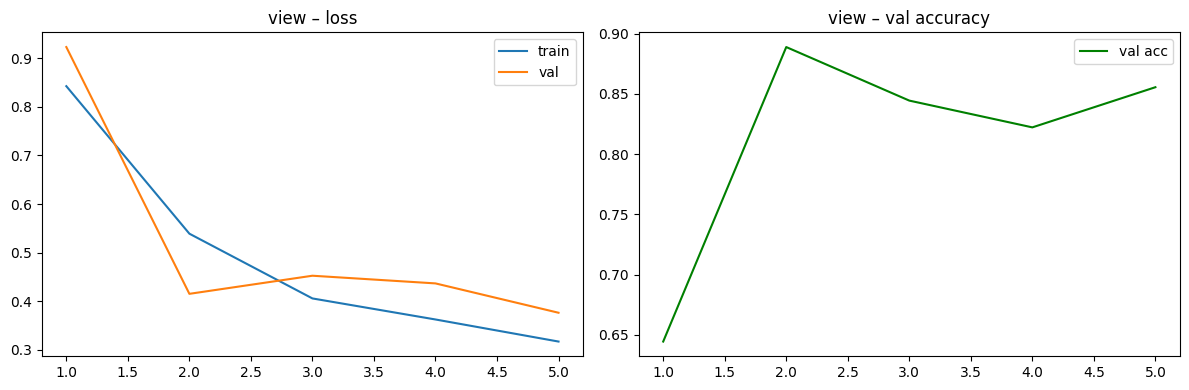


── view test report ──
              precision    recall  f1-score   support

  MediumView       0.68      0.65      0.67        23
   OuterView       0.85      0.77      0.81        22
    ShotView       0.73      0.73      0.73        22
    longView       0.85      0.96      0.90        23

    accuracy                           0.78        90
   macro avg       0.78      0.78      0.78        90
weighted avg       0.78      0.78      0.78        90



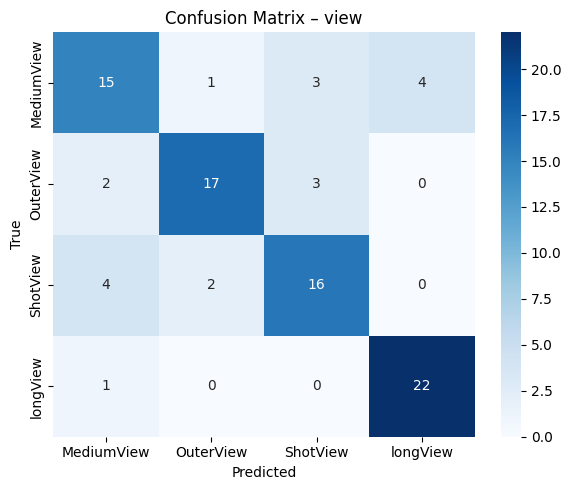

In [8]:
# ── Train VIEW classifier (MediumView, OuterView, ShotView, longView) ──────
view_model, view_classes = train_task(VIEW_MANIFEST, 'view_idx', 'baseline_cnn_view.pth', 'view')

## Outputs

- `outputs/baseline_cnn_event.pth` — event model + class list  
- `outputs/baseline_cnn_view.pth`  — view model + class list  
- `outputs/baseline_event_curves.png`, `outputs/baseline_view_curves.png`  
- `outputs/baseline_event_confusion_matrix.png`, `outputs/baseline_view_confusion_matrix.png`

➡️ Continue with **`03_baseline_gradcam.ipynb`** to inspect what the event model focuses on.
